In [1]:
#Vmin: 0.10 * Vmax (antatt)
#Tilsig: estimert fra magasinendring
#Begrensninger:
#    - Maks vannføring (Q_max)
#    - Magasinbegrensninger (Vmin, Vmax)
#    - Virkningsgrad
#    - Dysebegrensninger
#Optimalisering: B (med vannverdi)
#Nivå: Medium (nær avansert)

Antall timer etter utfylling: 8760
                Datetime  Price_ore_kWh
2112 2025-03-30 00:00:00         1.9200
2113 2025-03-30 01:00:00         2.0220
2114 2025-03-30 02:00:00         2.0445
2115 2025-03-30 03:00:00         2.0670
2116 2025-03-30 04:00:00         2.2360
             Datetime  Price_ore_kWh
0 2025-01-01 00:00:00          8.457
1 2025-01-01 01:00:00          7.030
2 2025-01-01 02:00:00          6.688
3 2025-01-01 03:00:00          6.499
4 2025-01-01 04:00:00          6.770
Antall timer: 8760
Fra: 2025-01-01 00:00:00
Til: 2025-12-31 23:00:00
Årlig tilsig: 158.998 millioner m³/år
Gjennomsnittlig tilsig: 5.041793505834602 m³/s
Min tilsig: 1.4840763142174433 m³/s
Max tilsig: 12.367302618478694 m³/s
t=0, pris=8.46, valgt Q=0.000, P=0.00, eta=0.000, V etter valg=86940000.00
t=1, pris=7.03, valgt Q=0.000, P=0.00, eta=0.000, V etter valg=86945342.67
t=2, pris=6.69, valgt Q=0.000, P=0.00, eta=0.000, V etter valg=86950685.35
t=3, pris=6.50, valgt Q=0.000, P=0.00, eta=0.000, V 

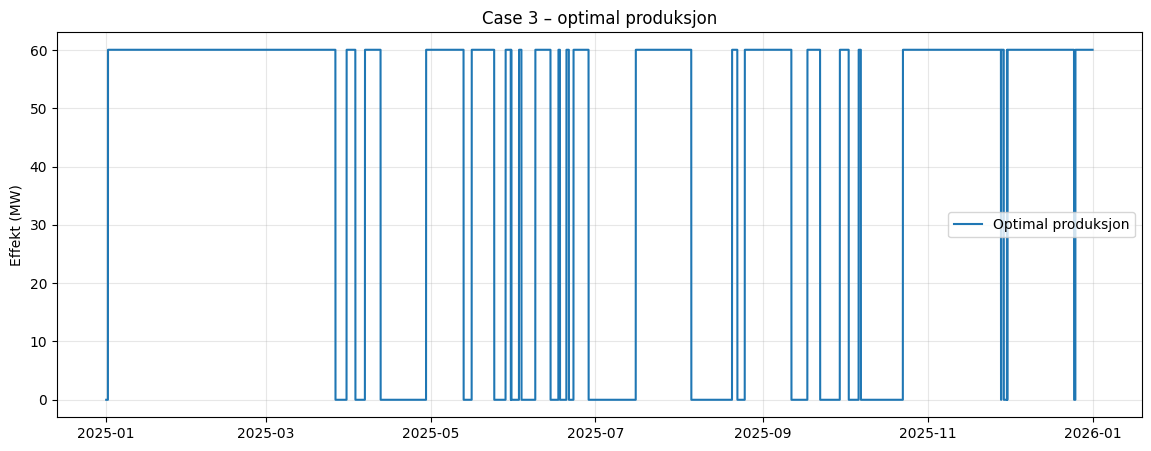

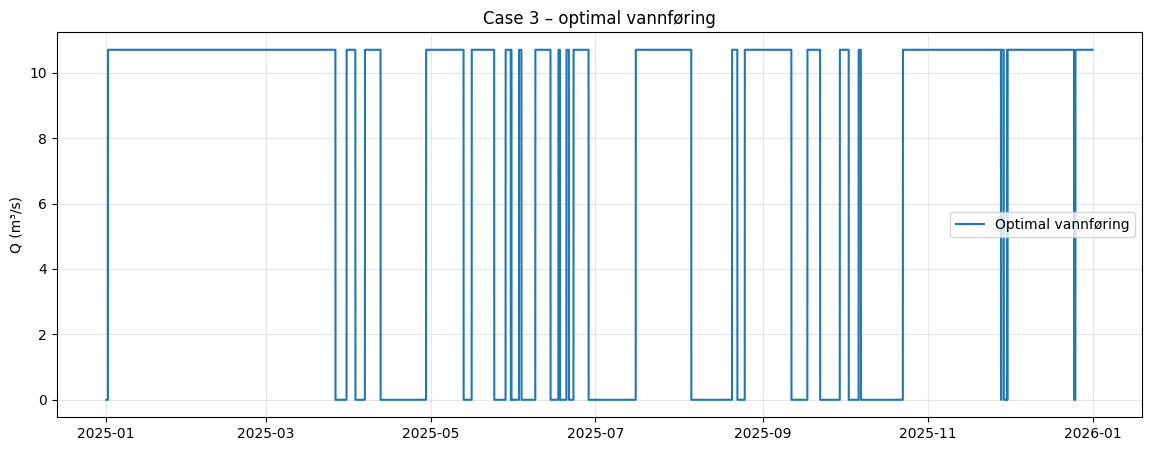

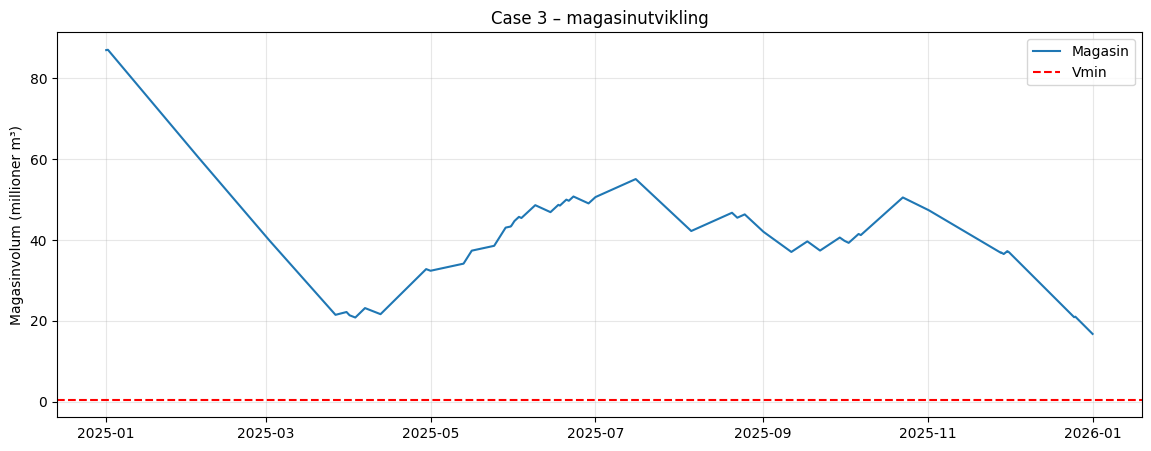

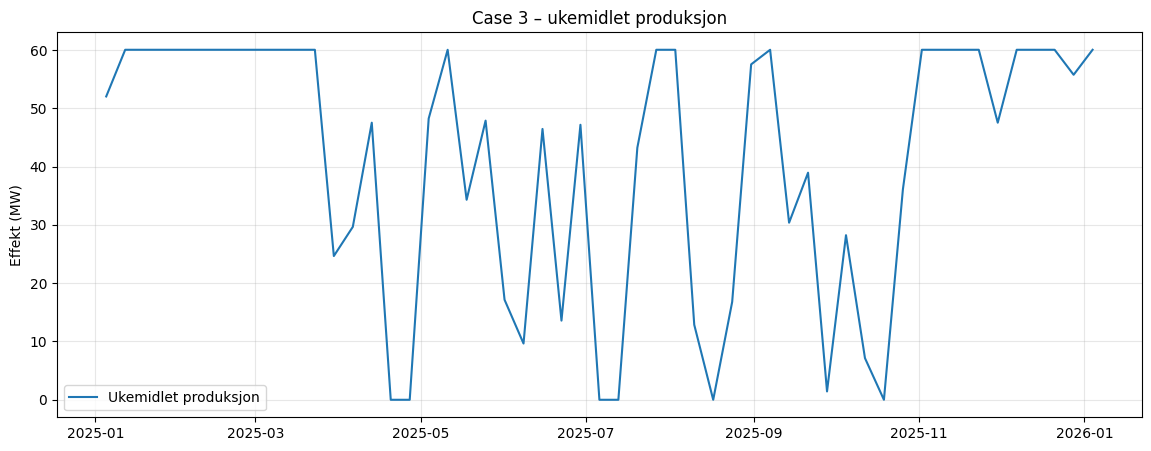

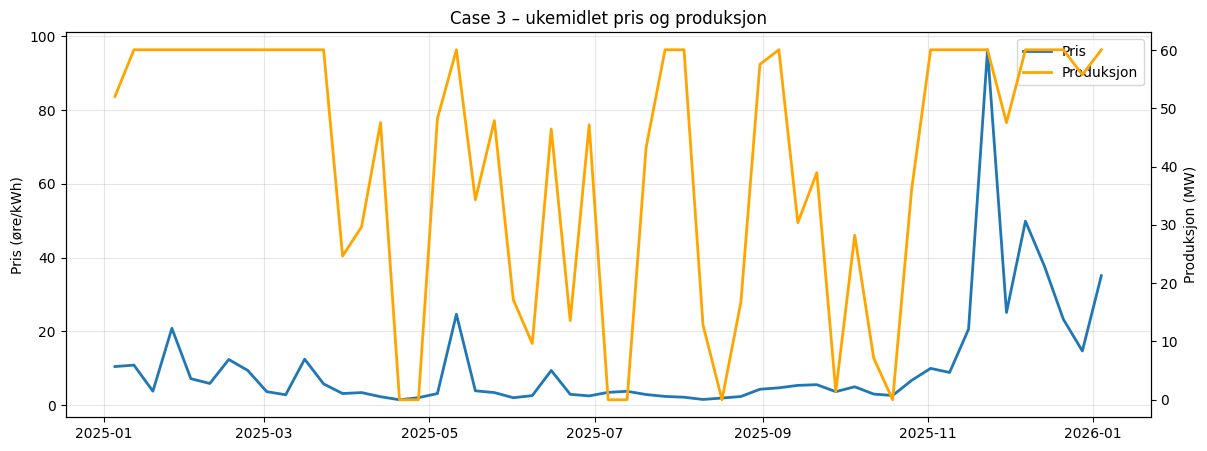

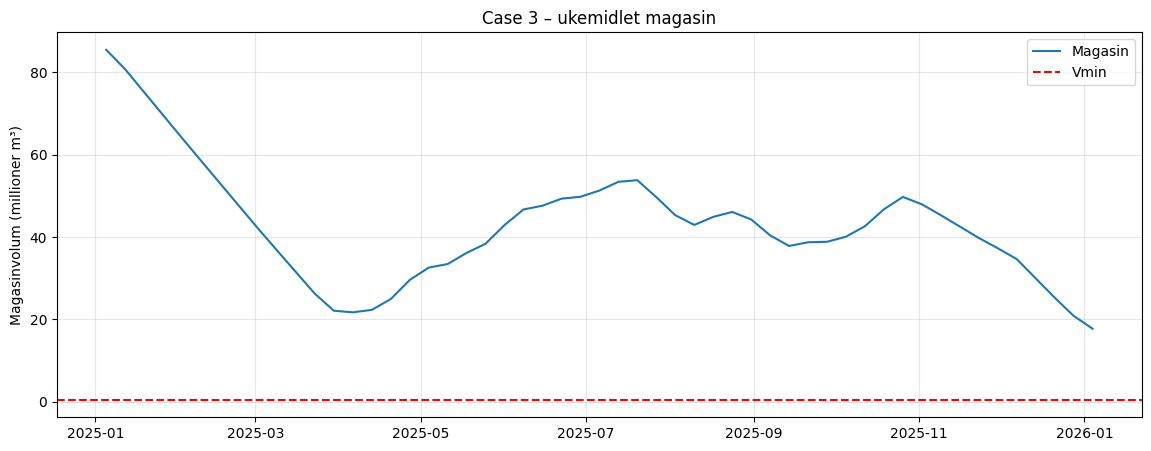

In [ ]:
# Case 3: Prisoptimalisert drift (Uten vannverdi, realistiske driftsgrenser)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Pris_2025 (1).xlsx", engine="openpyxl")

df = df.rename(columns={
    "Dato, time": "Datetime",
    "Gjennomsnitt Pris (øre/kWh)": "Price_ore_kWh"
})

df["Datetime"] = pd.to_datetime(df["Datetime"])
df["Price_ore_kWh"] = pd.to_numeric(df["Price_ore_kWh"], errors="coerce")

df = df.dropna(subset=["Datetime", "Price_ore_kWh"]).copy()
df = df.sort_values("Datetime").reset_index(drop=True)

nT = len(df)
prices = df["Price_ore_kWh"].to_numpy()

full_range = pd.date_range(
    start="2025-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="h"
)

df = df.set_index("Datetime").reindex(full_range)

df["Price_ore_kWh"] = df["Price_ore_kWh"].interpolate()

df = df.reset_index().rename(columns={"index": "Datetime"})

nT = len(df)
prices = df["Price_ore_kWh"].to_numpy()

print("Antall timer etter utfylling:", nT)
print(df.loc[df["Datetime"].between("2025-03-30 00:00", "2025-03-30 04:00")])

print(df.head())
print("Antall timer:", nT)
print("Fra:", df["Datetime"].min())
print("Til:", df["Datetime"].max())

# Tilsig og magasinparametere

Vmax = 94.5e6     # m^3  (hentet fra nordkraft.no)
Vmin = 0.5e6
V0 = 0.92 * Vmax  

annual_inflow_m3 = 158.998e6 # m³/år fra NVE REGINE

fordelingsfaktorer = np.array([
    0.3, 0.3, 0.4, 1.5, 2.5, 1.4,
    0.7, 0.7, 1.0, 1.4, 1.2, 0.6
])

dager_per_maaned = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
timer_per_maaned = dager_per_maaned * 24

# Fordel årsvolumet på måneder
maanedsvolum = annual_inflow_m3 * fordelingsfaktorer / fordelingsfaktorer.sum()

# m³/time per måned
tilsig_per_maaned_h = maanedsvolum / timer_per_maaned

# Timeserie med tilsig
inflow_hourly = np.repeat(tilsig_per_maaned_h, timer_per_maaned)

# Tilpass lengde til datasettet
inflow_hourly = inflow_hourly[:len(df)]

# m³/s kun for kontroll
inflow_m3_per_s = inflow_hourly / 3600

print("Årlig tilsig:", annual_inflow_m3 / 1e6, "millioner m³/år")
print("Gjennomsnittlig tilsig:", np.mean(inflow_m3_per_s), "m³/s")
print("Min tilsig:", np.min(inflow_m3_per_s), "m³/s")
print("Max tilsig:", np.max(inflow_m3_per_s), "m³/s")

# Fysiske parametere for kraftproduksjon

rho = 1000        # kg/m^3
g = 9.81          # m/s^2
H_brutto = 655    # m
Q_max = 10.7      # m^3/s

# Falltap-punkter hentet fra teknisk Excel-ark
# Q [m^3/s]  ->  falltap [m]
Q_loss_points = np.array([11.0, 16.5, 22.0])
h_loss_points = np.array([5.2, 10.5, 14.3])


k_loss = 5.2 / (11.0**2)

def h_loss(Q):
    """
    Beregner falltap som funksjon av vannføring.

    Antakelser:
    - For Q < 11 m^3/s brukes en kvadratisk sammenheng:
          h_loss = k * Q^2
      Dette gir fysisk riktig oppførsel ved lav vannføring.

    - For Q >= 11 m^3/s brukes lineær interpolasjon mellom
      beregnede punkter fra Excel-arket.

    Dermed bruker vi tekniske data direkte der vi har dem,
    men unngår urealistisk konstant falltap ved lav Q.
    """
    if np.isscalar(Q):
        if Q < 11.0:
            return k_loss * Q**2
        return np.interp(Q, Q_loss_points, h_loss_points)

    Q = np.asarray(Q)
    out = np.empty_like(Q, dtype=float)

    mask_low = Q < 11.0
    out[mask_low] = k_loss * Q[mask_low]**2
    out[~mask_low] = np.interp(Q[~mask_low], Q_loss_points, h_loss_points)

    return out

def H_netto(Q):
    """
    Netto fallhøyde = brutto fallhøyde - falltap
    """
    return H_brutto - h_loss(Q)

# Virkningsgrad som funksjon av vannføring

eta_max = 0.93

def eta_turbin(Q):
    if np.isscalar(Q):
        if Q <= 0:
            return 0.0

        q_rel = Q / Q_max

        if q_rel < 0.25:
            return 0.0
        elif q_rel < 0.50:
            # stigende del
            return 0.65 + (q_rel - 0.30) * (0.88 - 0.65) / (0.20)
        elif q_rel < 0.90:
            # bredt platå
            return 0.85 + 0.07 * (1 - ((q_rel - 0.70) / 0.20)**2)
        elif q_rel <= 1.00:
            # svak nedgang mot maks vannføring
            return 0.88

    Q = np.asarray(Q, dtype=float)
    out = np.zeros_like(Q, dtype=float)

    q_rel = Q / Q_max

    mask1 = (q_rel >= 0.30) & (q_rel < 0.50)
    out[mask1] = 0.65 + (q_rel[mask1] - 0.30) * (0.88 - 0.65) / (0.20)

    mask2 = (q_rel >= 0.60) & (q_rel < 0.90)
    out[mask2] = 0.88 + 0.04 * (1 - ((q_rel[mask2] - 0.75) / 0.15)**2)

    mask3 = (q_rel >= 0.90) & (q_rel <= 1.00)
    out[mask3] = 0.88 - (q_rel[mask3] - 0.90) * (0.88 - 0.80) / 0.10

    return out

# Effekt som funksjon av vannføring

def power_MW(Q):
    Hn = H_netto(Q)
    eta = eta_turbin(Q)
    P = rho * g * Q * Hn * eta / 1e6
    return P, eta, Hn

# Valgt realistiske driftsgrenser for Case 3

Q_candidates = np.linspace(0, Q_max, 200)

Q_out = np.zeros(nT)
P_out = np.zeros(nT)
eta_out = np.zeros(nT)
Hn_out = np.zeros(nT)
revenue_out = np.zeros(nT)
V = np.zeros(nT)

V[0] = V0

# Valgte realistiske driftsgrenser for Case 3
max_delta_Q = 1.0         # m^3/s per time
Q_min = 5.0               # minste vannføring når anlegget først går
P_min = 45.0              # minste effekt når anlegget først går
# Kanskje spør om denne verdien? Hva er realistisk minimumseffekt for et anlegg av denne størrelsen?
startup_cost_ore = 500000  # straff for oppstart. Verdi fra Matthew
ramp_penalty_coeff = 10000 # straff for raske endringer i Q.

for t in range(nT):

    if t > 0:
        V[t] = V[t-1] + inflow_hourly[t]

    # Magasin kan ikke overstige Vmax
    if V[t] > Vmax:
        V[t] = Vmax

# 3: Prisoptimalisert drift uten vann

    best_revenue = 0.0
    best_Q = 0.0
    best_P = 0.0
    best_eta = 0.0
    best_Hn = H_netto(0)

    # Forrige times vannføring brukes til ramping/startkostnad
    prev_Q = Q_out[t-1] if t > 0 else 0.0

    for Q in Q_candidates:

        water_use = Q * 3600  # m^3 brukt denne timen

        # Magasinet kan ikke tappes under minimumsnivå
        if V[t] - water_use < Vmin:
            continue

        # Ramping gjelder bare når anlegget allerede er i drift.
        # Vi tillater større sprang ved oppstart fra 0.
        if prev_Q > 0 and abs(Q - prev_Q) > max_delta_Q:
            continue

        # Hvis vi først produserer, skal vi ikke ligge på veldig lav vannføring
        if Q > 0 and Q < Q_min:
            continue

        # Beregn effekt, virkningsgrad og netto fallhøyde
        P, eta, Hn = power_MW(Q)

        # Hvis vi først produserer, skal vi ikke ligge på veldig lav effekt
        if Q > 0 and P < P_min:
            continue

        # Inntekt denne timen
        revenue_raw = prices[t] * 1000 * P

        # Realistiske straffer
        ramp_penalty = ramp_penalty_coeff * abs(Q - prev_Q)
        startup_cost = startup_cost_ore if (prev_Q == 0.0 and Q > 0.0) else 0.0

        # CASE 3:
        # Ingen vannverdi og ingen water_cost her
        revenue = revenue_raw - ramp_penalty - startup_cost

        # Velg beste lovlige driftspunkt
        if revenue > best_revenue:
            best_revenue = revenue
            best_Q = Q
            best_P = P
            best_eta = eta
            best_Hn = Hn

# Lagre resultater for denne timen

    Q_out[t] = best_Q
    P_out[t] = best_P
    eta_out[t] = best_eta
    Hn_out[t] = best_Hn
    revenue_out[t] = best_revenue


    V[t] -= best_Q * 3600

    if V[t] < Vmin:
        V[t] = Vmin

    if t < 5:
        print(f"t={t}, pris={prices[t]:.2f}, valgt Q={best_Q:.3f}, "
              f"P={best_P:.2f}, eta={best_eta:.3f}, V etter valg={V[t]:.2f}")


# Resultater i DataFrame

results = pd.DataFrame({
    "Datetime": df["Datetime"],
    "Price_ore_kWh": prices,
    "Q_opt_m3s": Q_out,
    "P_opt_MW": P_out,
    "eta_opt": eta_out,
    "H_netto_m": Hn_out,
    "Magasin_m3": V,
    "Revenue_ore_per_h": revenue_out
})

# Nøkkeltall for Case 3
total_energy_MWh = results["P_opt_MW"].sum()
total_revenue_NOK = results["Revenue_ore_per_h"].sum() / 100
avg_eta = results.loc[results["P_opt_MW"] > 0, "eta_opt"].mean()
drift_hours = (results["P_opt_MW"] > 0).sum()

starts = (
    (results["Q_opt_m3s"] > 0) &
    (results["Q_opt_m3s"].shift(1, fill_value=0) == 0)
).sum()

print("\n=== NØKKELTALL CASE 3 ===")
print(f"Total energi: {total_energy_MWh:.1f} MWh")
print(f"Total inntekt: {total_revenue_NOK:,.0f} kr")
print(f"Gjennomsnittlig virkningsgrad i drift: {avg_eta*100:.2f} %")
print(f"Driftstimer: {drift_hours}")
print(f"Antall oppstarter: {starts}")

print(results.head())
print(results.describe())

print(results[["Q_opt_m3s", "P_opt_MW"]].describe())
print(results[["Q_opt_m3s", "P_opt_MW"]].head(20))


results["Revenue_ore_per_h"] = results["P_opt_MW"] * 1000 * results["Price_ore_kWh"]

total_energy_MWh = results["P_opt_MW"].sum()
total_revenue_NOK = results["Revenue_ore_per_h"].sum() / 100
avg_eta = results.loc[results["P_opt_MW"] > 0, "eta_opt"].mean() * 100
drift_hours = (results["P_opt_MW"] > 0).sum()
starts = ((results["P_opt_MW"] > 0) & (results["P_opt_MW"].shift(1, fill_value=0) == 0)).sum()

print("=== NØKKELTALL CASE 3 ===")
print(f"Total energi: {total_energy_MWh:.1f} MWh")
print(f"Total inntekt: {total_revenue_NOK:,.0f} kr")
print(f"Gjennomsnittlig virkningsgrad i drift: {avg_eta:.2f} %")
print(f"Driftstimer: {drift_hours}")
print(f"Antall oppstarter: {starts}")

# PLOTS CASE 3 - PRISOPTIMALISERT DRIFT

results["Datetime"] = pd.to_datetime(results["Datetime"])

# 1. Produksjon
plt.figure(figsize=(14, 5))
plt.plot(results["Datetime"], results["P_opt_MW"], label="Optimal produksjon")
plt.title("Case 3 - optimal produksjon")
plt.ylabel("Effekt (MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 2. Vannføring
plt.figure(figsize=(14, 5))
plt.plot(results["Datetime"], results["Q_opt_m3s"], label="Optimal vannføring")
plt.title("Case 3 - optimal vannføring")
plt.ylabel("Q (m³/s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 3. Magasin
plt.figure(figsize=(14, 5))
plt.plot(results["Datetime"], results["Magasin_m3"] / 1e6, label="Magasin")
plt.axhline(Vmin / 1e6, color="red", linestyle="--", label="Vmin")
plt.title("Case 3 - magasinutvikling")
plt.ylabel("Magasinvolum (millioner m³)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 4. Ukemidlet produksjon
results_plot = results.copy()
results_plot = results_plot.set_index("Datetime")
weekly = results_plot.resample("W").mean(numeric_only=True)

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly["P_opt_MW"], label="Ukemidlet produksjon")
plt.title("Case 3 - ukemidlet produksjon")
plt.ylabel("Effekt (MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# 5. Ukemidlet pris og produksjon
plt.figure(figsize=(14, 5))

ax1 = plt.gca()
ax1.plot(weekly.index, weekly["Price_ore_kWh"], label="Pris", linewidth=2)
ax1.set_ylabel("Pris (øre/kWh)")
ax1.set_title("Case 3 - ukemidlet pris og produksjon")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly["P_opt_MW"], label="Produksjon", linewidth=2, color="orange")
ax2.set_ylabel("Produksjon (MW)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()


# 6. Ukemidlet magasin
plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly["Magasin_m3"] / 1e6, label="Magasin")
plt.axhline(Vmin / 1e6, color="red", linestyle="--", label="Vmin")
plt.title("Case 3 - ukemidlet magasin")
plt.ylabel("Magasinvolum (millioner m³)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

